# Basic IEEE14 Example


### Activation Environment and Import Packages

In [64]:
using Pkg
Pkg.activate("./env")
using ImportAll
@importall(MarinePowerDynamics)
include("./src/plotexample.jl")

  Activating project at `~/research/MarinePowerDynamics.jl/example/env`


create_plot (generic function with 1 method)

### Build IEEE 14 Bus System 

This cell below builds our modified IEEE 14 bus system. We added our Linear PTO model to the system at Bus 15


In [56]:
# You don't need to run the build cell again if you have already built the power grid. uncomment this

#powergrid = read_powergrid(joinpath(@__DIR__,"./src/WEC_IEEE14grid.json"), Json)

In [57]:
using OrderedCollections: OrderedDict
buses=OrderedDict(
    "bus1"=> FourthOrderEq(T_d_dash=7.4, D=2, X_d=0.8979, X_q=0.646, Ω=50, X_d_dash=0.2995, T_q_dash=0.1, X_q_dash=0.646, P=2.32, H=5.148, E_f=1),
    "bus2"=> SlackAlgebraic(U=1),
    "bus3"=> FourthOrderEq(T_d_dash=6.1, D=2, X_d=1.05, X_q=0.98, Ω=50, X_d_dash=0.185, T_q_dash=0.4, X_q_dash=0.36, P=-0.942, H=6.54, E_f= 1),
    "bus4"=> PQAlgebraic(P=-0.478, Q=-0.0),
    "bus5"=> PQAlgebraic(P=-0.076, Q=-0.016),
    "bus6"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=-0.122, H=5.06, E_f= 1),
    "bus7"=> PQAlgebraic(P=-0.0, Q=-0.0),
    "bus8"=> FourthOrderEq(T_d_dash=4.75, D=2, X_d=1.25, X_q=1.22, Ω=50, X_d_dash=0.232, T_q_dash=1.6, X_q_dash=0.715, P=0.0, H=5.06, E_f= 1),
    "bus9"=> PQAlgebraic(P=-0.295, Q=-0.166),
    "bus10"=> PQAlgebraic(P=-0.09, Q=-0.058),
    "bus11"=> PQAlgebraic(P=-0.035, Q=-0.018),
    "bus12"=> PQAlgebraic(P=-0.061, Q=-0.016),
    "bus13"=> PQAlgebraic(P=-0.135, Q=-0.058),
    "bus14"=> PQAlgebraic(P=-0.149, Q=-0.05),
    "bus15" => LinearPTO(τ_P=0.1,τ_Q=2.0,K_P=0.1,K_Q=0.1,V_r=1.0,Q=0,K_pto=0, C_pto=1200000, η=1.0, base_power=100e6, scaling_factor=10, sim_path="./src/RM3_data/simulation_data.csv"),
    );

branches=OrderedDict(
    "branch1"=> PiModelLine(from= "bus1", to = "bus2",y=4.999131600798035-1im*15.263086523179553, y_shunt_km=0.0528/2, y_shunt_mk=0.0528/2),
    "branch2"=> PiModelLine(from= "bus1", to = "bus5",y=1.025897454970189-1im*4.234983682334831, y_shunt_km=0.0492/2, y_shunt_mk=0.0492/2),
    "branch3"=> PiModelLine(from= "bus2", to = "bus3",y=1.1350191923073958-1im*4.781863151757718, y_shunt_km=0.0438/2, y_shunt_mk=0.0438/2),
    "branch4"=> PiModelLine(from= "bus2", to = "bus4",y=1.686033150614943-1im*5.115838325872083, y_shunt_km=0.0340/2, y_shunt_mk=0.0340/2),
    "branch5"=> PiModelLine(from= "bus2", to = "bus5",y=1.7011396670944048-1im*5.193927397969713, y_shunt_km=0.0346/2, y_shunt_mk=0.0346/2),
    "branch6"=> PiModelLine(from= "bus3", to = "bus4",y=1.9859757099255606-1im*5.0688169775939205, y_shunt_km=0.0128/2, y_shunt_mk=0.0128/2),
    "branch7"=> StaticLine(from= "bus4", to = "bus5",Y=6.840980661495672-1im*21.578553981691588),
    "branch8"=> Transformer(from= "bus4", to = "bus7", y=0.0-1im*4.781943381790359, t_ratio=0.978),
    "branch9"=> Transformer(from= "bus4", to = "bus9", y=0.0-1im*1.7979790715236075, t_ratio=0.969),
    "branch10"=> Transformer(from= "bus5", to = "bus6", y=0.0-1im*3.967939052456154, t_ratio=0.932),
    "branch11"=> StaticLine(from= "bus6", to = "bus11",Y=1.9550285631772604-1im*4.0940743442404415),
    "branch12"=> StaticLine(from= "bus6", to = "bus12",Y=1.525967440450974-1im*3.1759639650294003),
    "branch13"=> StaticLine(from= "bus6", to = "bus13",Y=3.0989274038379877-1im*6.102755448193116),
    "branch14"=> StaticLine(from= "bus7", to = "bus8",Y=0.0-1im*5.676979846721544),
    "branch15"=> StaticLine(from= "bus7", to = "bus9",Y=0.0-1im*9.09008271975275),
    "branch16"=> StaticLine(from= "bus9", to = "bus10",Y=3.902049552447428-1im*10.365394127060915),
    "branch17"=> StaticLine(from= "bus9", to = "bus14",Y=1.4240054870199312-1im*3.0290504569306034),
    "branch18"=> StaticLine(from= "bus10", to = "bus11",Y=1.8808847537003996-1im*4.402943749460521),
    "branch19"=> StaticLine(from= "bus12", to = "bus13",Y=2.4890245868219187-1im*2.251974626172212),
    "branch20"=> StaticLine(from= "bus13", to = "bus14",Y=1.1369941578063267-1im*2.314963475105352),
    "branch21"=> StaticLine(from= "bus6", to = "bus15",Y=2.0-1im*5.0));

powergrid = PowerGrid(buses, branches)
write_powergrid(powergrid, joinpath(@__DIR__,"./src/WEC_IEEE14grid.json"), Json)

In [58]:
### Grab grid file 
powergrid = read_powergrid(joinpath(@__DIR__,"./src/WEC_IEEE14grid.json"), Json)

PowerGrid(Graphs.SimpleGraphs.SimpleGraph{Int64}(21, [[2, 5], [1, 3, 4, 5], [2, 4], [2, 3, 5, 7, 9], [1, 2, 4, 6], [5, 11, 12, 13, 15], [4, 8, 9], [7], [4, 7, 10, 14], [9, 11], [6, 10], [6, 13], [6, 12, 14], [9, 13], [6]]), OrderedDict{String, AbstractNode}("bus1" => FourthOrderEq(5.148, 2.32, 2, 50, 1, 7.4, 0.1, 0.646, 0.2995, 0.8979, 0.646, 0), "bus2" => SlackAlgebraic(1, 0), "bus3" => FourthOrderEq(6.54, -0.942, 2, 50, 1, 6.1, 0.4, 0.36, 0.185, 1.05, 0.98, 0), "bus4" => PQAlgebraic(-0.478, -0.0, 0), "bus5" => PQAlgebraic(-0.076, -0.016, 0), "bus6" => FourthOrderEq(5.06, -0.122, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus7" => PQAlgebraic(-0.0, -0.0, 0), "bus8" => FourthOrderEq(5.06, 0.0, 2, 50, 1, 4.75, 1.6, 0.715, 0.232, 1.25, 1.22, 0), "bus9" => PQAlgebraic(-0.295, -0.166, 0), "bus10" => PQAlgebraic(-0.09, -0.058, 0)…), OrderedDict{Any, Any}("branch1" => PiModelLine("bus1", "bus2", 4.999131600798035 - 15.263086523179553im, 0.0264, 0.0264), "branch2" => PiModelLine("bus

0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0


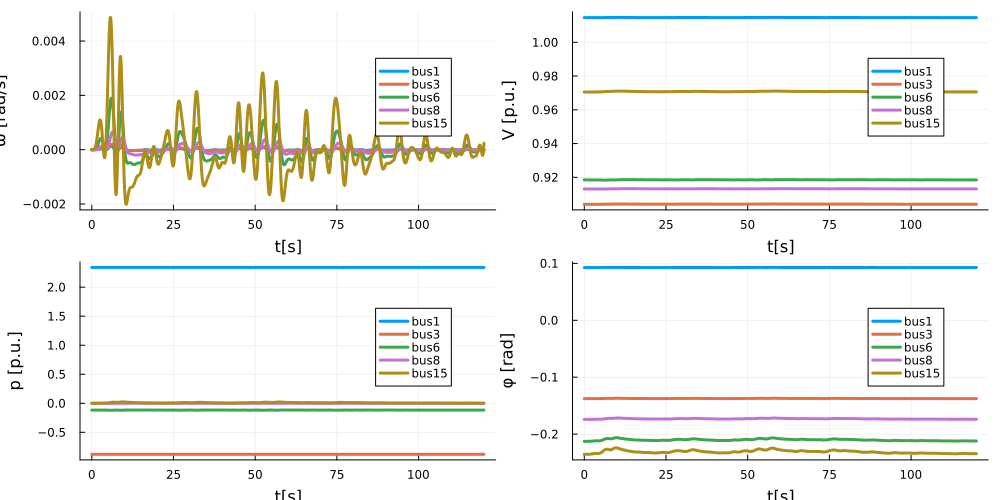

In [59]:
### flat run test

operationpoint = find_operationpoint(powergrid)

# Configuration for the simulation
# notice the fault span is after the simulation start time to run a flat run
config = Dict(
    "fault_span" => (120.1, 120.2),
    "component" => "branch1",
    "timespan" => (0.0, 120.0)
)
fault = LineFailure(line_name = config["component"], tspan_fault = config["fault_span"])

# run dynamic simulation
solution = simulate(fault, powergrid, operationpoint, config["timespan"])

create_plot(solution)

0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0
0.0:0.012001200120012:120.0


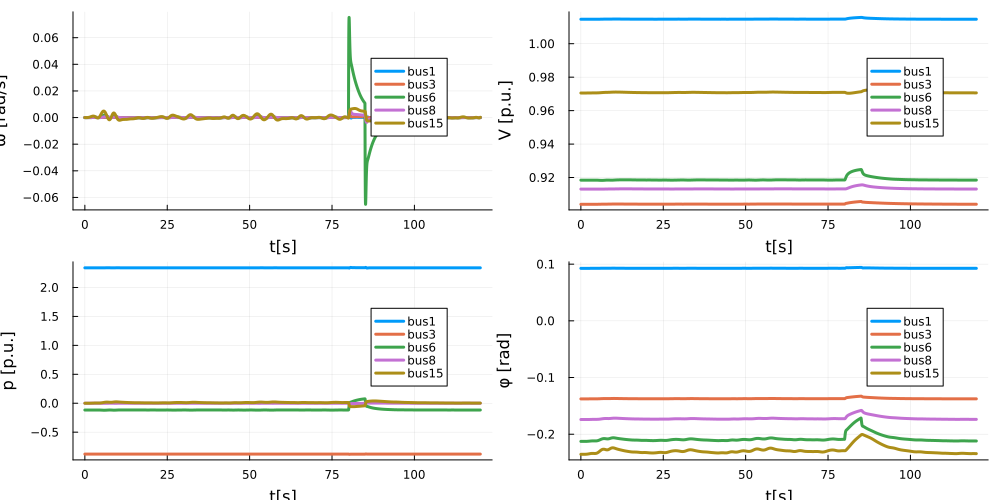

In [60]:
### fault test: 

operationpoint = find_operationpoint(powergrid)

# Configuration for the simulation
# notice the fault span is after the simulation start time to run a flat run
config = Dict(
    "fault_span" => (80, 85),
    "component" => "bus6",
    "timespan" => (0.0, 120.0)
)
fault = NodeParameterChange(node = config["component"], tspan_fault = config["fault_span"], value=0.1, var=:P)

# run dynamic simulation
solution = simulate(fault, powergrid, operationpoint, config["timespan"])

create_plot(solution)
